In [1]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\06. Rock Abundance\tes_rock_abundance_numeric.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Rock_Abundance": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("rock_abundance.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude  Rock_Abundance
0        0.5       0.5               0
1        1.5       0.5               0
2        2.5       0.5               0
3        3.5       0.5               0
4        4.5       0.5               0


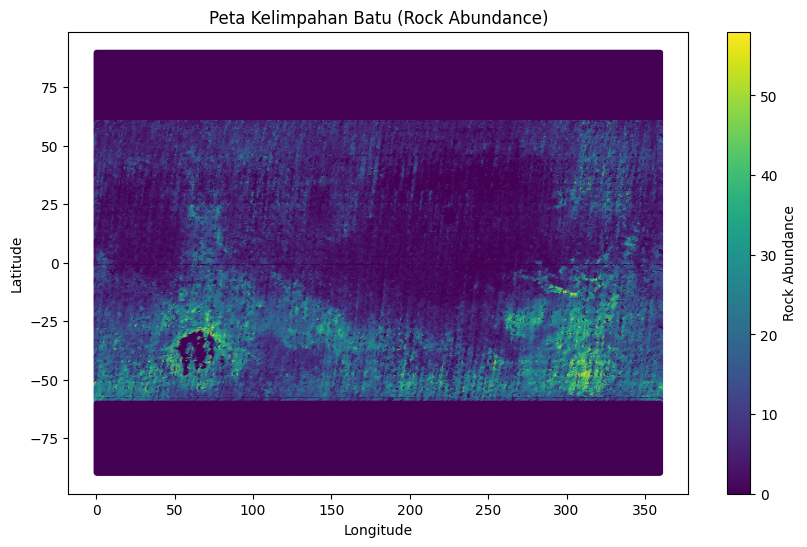

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\06. Rock Abundance\rock_abundance.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 720
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 360)


# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Rock_Abundance"], cmap="viridis", s=10)
plt.colorbar(label="Rock Abundance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Kelimpahan Batu (Rock Abundance)")


plt.show()

In [5]:
df_after0 = df_bersih[(df_bersih["Rock_Abundance"] >= 0)]
print(df_after0.head())

   Longitude  Latitude  Rock_Abundance
0       0.25     89.75               0
1       0.75     89.75               0
2       1.25     89.75               0
3       1.75     89.75               0
4       2.25     89.75               0


In [6]:
counts_after0 = df_after0["Rock_Abundance"].value_counts().sort_index()

print(counts_after0)

Rock_Abundance
0     115932
1       4246
2       9008
3       9841
4       9294
5       8779
6       8149
7       7426
8       6689
9       6327
10      5919
11      5471
12      5153
13      4835
14      4468
15      4435
16      4205
17      3960
18      3686
19      3406
20      3163
21      2776
22      2565
23      2314
24      2179
25      1769
26      1687
27      1528
28      1232
29      1201
30      1006
31       834
32       828
33       607
34       596
35       527
36       448
37       358
38       343
39       306
40       250
41       220
42       175
43       188
44       153
45       125
46       100
47       104
48        75
49        59
50        43
51        42
52        39
53        30
54        23
55        26
56        18
57        18
58        16
Name: count, dtype: int64


In [7]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_after0["Longitude"], df_after0["Latitude"], c=df_after0["Roughness"], cmap="viridis", s=10)
plt.colorbar(label="Roughness")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Kekasaran Permukaan (Roughness) 0.6km (Roughness >= 0)")


plt.show()

KeyError: 'Roughness'

<Figure size 1000x600 with 0 Axes>

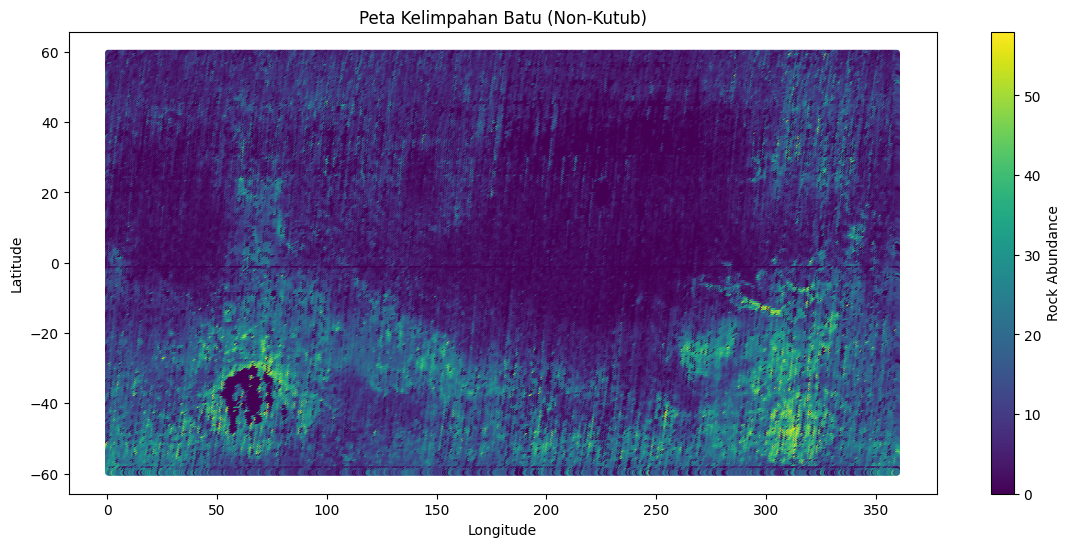

In [8]:
df_nonkutub = df_after0[(df_after0["Latitude"] < 60) & (df_after0["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Rock_Abundance"], cmap="viridis", s=10)
plt.colorbar(label="Rock Abundance")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Kelimpahan Batu (Non-Kutub)")

plt.show()